# Isolating per-event STDP jump size from Apre's accumulation rate

Per Jasper's message (relayed via Claude web chat, 2026-07-20). The scaling-interval
hypothesis was cleanly rejected (500ms down to 10ms, zero effect on the Apre=0.02
instability). Better-supported explanation, not yet tested: synaptic scaling only
constrains the *aggregate* weight sum — it never touches the size of a single STDP event's
weight jump. At Apre=0.02, an individual spike-pairing event can swing one synapse's weight
by a large amount in one step (via the `apre`/`apost` trace values, which can themselves grow
above the nominal `Apre`/`Apost` if multiple same-side spikes happen close together before
being consumed). Nothing currently caps that per-event jump, regardless of how often the sum
gets rebalanced.

**Test:** add an explicit cap on the per-event weight delta in the `on_pre`/`on_post` STDP
rules — clip the applied change to `±max_delta` (a fraction of the `[0,1]` weight range),
**independent of `Apre`**. This isolates jump-size from learning-rate: lowering `Apre` itself
would confound "smaller individual jumps" with "slower overall accumulation," so the cap is
applied as a separate clip on the delta actually added to `w`, not by changing `Apre`.

```
on_pre:  v_post += w*gmax; apre += Apre; w = clip(w + clip(apost, -max_delta, max_delta), 0, wmax)
on_post: apost += Apost;   w = clip(w + clip(apre, -max_delta, max_delta), 0, wmax)
```

**Pre-specified conditions**, all at `Apre=0.02, p_share=0.9`, 300s, `scaling_interval=500ms`
(reverting to the original default — the interval sweep showed it doesn't matter):
uncapped (baseline, should reproduce the known chaotic instability), `max_delta` in
{0.05, 0.02, 0.01}.

**Falsification criteria, stated before running:**
- **Confirms:** capping produces genuine visible settling — trajectory plot shows the
  correlated/uncorrelated groups separating and *holding*, matching the qualitative shape
  `Apre=0.005` already shows, at one or more tested caps.
- **Rejects:** instability persists even at the smallest cap (0.01) — flag for a different
  explanation, don't shrink the cap further indefinitely chasing a value that happens to work.
- **Also checking, since a cap could "fix" instability by breaking the actual result instead:**
  does real differentiation (`corr_w > uncorr_w`) still emerge at the capped settings, not
  just non-chaotic behavior? A cap tight enough to prevent any real potentiation would produce
  a stable-looking but non-differentiating (and therefore equally useless) result.

Trajectory plots are the real test throughout — not endpoint diffs, per the exact trap that
was just caught in the previous round.

In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

prefs.codegen.target = 'cython'
seed(42)
np.random.seed(42)
print("Brian2", __import__('brian2').__version__)

Brian2 2.9.0


## Reused, unchanged: neuron params, spike generators, calibrated `gmax`/`w_init`, homeostatic scaling (500ms interval, confirmed not the lever that matters)

In [2]:
tau = 10*ms
v_rest = -70*mV
v_thresh = -50*mV
v_reset = -65*mV
t_ref = 5*ms

post_eqs = '''
dv/dt = (v_rest - v)/tau : volt (unless refractory)
w_total : 1
'''

def poisson_times(rate_hz, duration_s, rng):
    n_expected = int(rate_hz * duration_s * 1.5) + 10
    isi = rng.exponential(1.0 / rate_hz, size=n_expected)
    times = np.cumsum(isi)
    return times[times < duration_s]

def dedup_spike_times(times, min_gap=0.0002):
    if len(times) == 0:
        return times
    times = np.sort(times)
    keep = [times[0]]
    for t_val in times[1:]:
        if t_val - keep[-1] >= min_gap:
            keep.append(t_val)
    return np.array(keep)

def generate_correlated_group(n_neurons, target_rate_hz, p_share, duration_s, jitter_ms, rng):
    master_times = poisson_times(target_rate_hz, duration_s, rng)
    all_times, all_indices = [], []
    for i in range(n_neurons):
        keep = rng.random(len(master_times)) < p_share
        shared = master_times[keep] + rng.normal(0, jitter_ms / 1000.0, size=keep.sum())
        fill_rate = (1 - p_share) * target_rate_hz
        independent = poisson_times(fill_rate, duration_s, rng) if fill_rate > 0 else np.array([])
        combined = np.clip(np.concatenate([shared, independent]), 0, duration_s - 1e-6)
        combined = dedup_spike_times(combined)
        all_times.append(combined)
        all_indices.append(np.full(len(combined), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def generate_uncorrelated_group(n_neurons, target_rate_hz, duration_s, rng):
    all_times, all_indices = [], []
    for i in range(n_neurons):
        t = dedup_spike_times(poisson_times(target_rate_hz, duration_s, rng))
        all_times.append(t)
        all_indices.append(np.full(len(t), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def build_presynaptic_input(target_rate_hz, p_share, duration_s, rng, jitter_ms=2.0):
    corr_idx, corr_t = generate_correlated_group(10, target_rate_hz, p_share, duration_s, jitter_ms, rng)
    uncorr_idx, uncorr_t = generate_uncorrelated_group(10, target_rate_hz, duration_s, rng)
    uncorr_idx = uncorr_idx + 10
    all_idx = np.concatenate([corr_idx, uncorr_idx]).astype(int)
    all_t = np.concatenate([corr_t, uncorr_t])
    order = np.argsort(all_t)
    return all_idx[order], all_t[order] * second

TARGET_RATE = 20.0
GMAX = 6*mV
W_INIT = 0.5
TARGET_TOTAL = 20 * W_INIT
SCALING_INTERVAL = 500*ms

taupre = 20*ms
taupost = 20*ms
wmax = 1.0
scaling_op = 'w = w * target_total / (w_total_post + 1e-9)'

print("Reused mechanism loaded.")

Reused mechanism loaded.


## STDP with an optional per-event jump cap

`max_delta=None` reproduces the exact uncapped mechanism from previous notebooks (baseline).
A finite `max_delta` clips the delta actually applied to `w` on each event, independent of
`Apre`/`Apost`'s own magnitude.

In [3]:
def make_stdp_rules(max_delta):
    if max_delta is None:
        on_pre = '''
        v_post += w*gmax
        apre += Apre
        w = clip(w+apost, 0, wmax)
        '''
        on_post = '''
        apost += Apost
        w = clip(w+apre, 0, wmax)
        '''
    else:
        on_pre = f'''
        v_post += w*gmax
        apre += Apre
        w = clip(w + clip(apost, -{max_delta}, {max_delta}), 0, wmax)
        '''
        on_post = f'''
        apost += Apost
        w = clip(w + clip(apre, -{max_delta}, {max_delta}), 0, wmax)
        '''
    return on_pre, on_post

stdp_model_homeo = '''
w : 1
w_total_post = w : 1 (summed)
dapre/dt = -apre/taupre : 1 (event-driven)
dapost/dt = -apost/taupost : 1 (event-driven)
'''

def run_stdp_jump_cap(p_share, Apre_val, duration_s, seed_val, max_delta):
    start_scope()
    Apre = Apre_val
    Apost = -Apre_val * (taupre/taupost) * 1.05
    target_total = TARGET_TOTAL
    on_pre, on_post = make_stdp_rules(max_delta)

    rng = np.random.default_rng(seed_val)
    idx, t = build_presynaptic_input(TARGET_RATE, p_share, duration_s, rng)

    pre = SpikeGeneratorGroup(20, idx, t)
    post = NeuronGroup(1, post_eqs, threshold='v>v_thresh', reset='v=v_reset',
                        refractory=t_ref, method='exact')
    post.v = v_rest

    syn = Synapses(pre, post, model=stdp_model_homeo, on_pre=on_pre, on_post=on_post,
                    namespace={'Apre': Apre, 'Apost': Apost, 'gmax': GMAX, 'target_total': target_total})
    syn.connect()
    syn.w = W_INIT
    syn.run_regularly(scaling_op, dt=SCALING_INTERVAL)

    post_spikes = SpikeMonitor(post)
    weight_trace = StateMonitor(syn, 'w', record=True, dt=500*ms)

    run(duration_s*second)

    final_w = np.array(syn.w[:])
    corr_w = final_w[:10]
    uncorr_w = final_w[10:]
    return {
        'max_delta': max_delta,
        'final_w': final_w, 'corr_w': corr_w, 'uncorr_w': uncorr_w,
        'post_rate': post_spikes.count[0] / duration_s,
        'weight_trace': weight_trace.w[:], 'trace_t': weight_trace.t / second,
    }

print("Jump-cap runner defined.")

Jump-cap runner defined.


## Run the 4 pre-specified conditions

In [4]:
cap_results = {}
for max_delta in [None, 0.05, 0.02, 0.01]:
    label = "uncapped" if max_delta is None else f"max_delta={max_delta}"
    print(f"{label} ...")
    res = run_stdp_jump_cap(0.9, 0.02, 300.0, seed_val=1000, max_delta=max_delta)
    cap_results[max_delta] = res
    print(f"  -> post_rate={res['post_rate']:.2f}Hz, corr_w={res['corr_w'].mean():.3f}, "
          f"uncorr_w={res['uncorr_w'].mean():.3f}, diff={res['corr_w'].mean()-res['uncorr_w'].mean():+.3f}")

print("\nAll 4 runs complete.")

uncapped ...


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([7.89518592e-03, 8.77162165e-03, 1.00571700e-02, ...,
       2.99982417e+02, 2.99996048e+02, 2.99996839e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post_rate=18.46Hz, corr_w=0.580, uncorr_w=0.397, diff=+0.182
max_delta=0.05 ...


WARNING    't' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value array([7.89518592e-03, 8.77162165e-03, 1.00571700e-02, ...,
       2.99982417e+02, 2.99996048e+02, 2.99996839e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post_rate=18.46Hz, corr_w=0.586, uncorr_w=0.402, diff=+0.184
max_delta=0.02 ...


  -> post_rate=18.68Hz, corr_w=0.590, uncorr_w=0.404, diff=+0.186
max_delta=0.01 ...


  -> post_rate=18.55Hz, corr_w=0.688, uncorr_w=0.307, diff=+0.381

All 4 runs complete.


## Trajectory plots — the real test

Endpoint diffs alone showed uncapped/0.05/0.02 nearly identical (~0.18) and 0.01 notably
different (+0.381) -- but per the exact lesson from the previous round, that doesn't tell us
about stability. Plotting full trajectories, and the late-window variance/gap-trend check,
before drawing any conclusion.

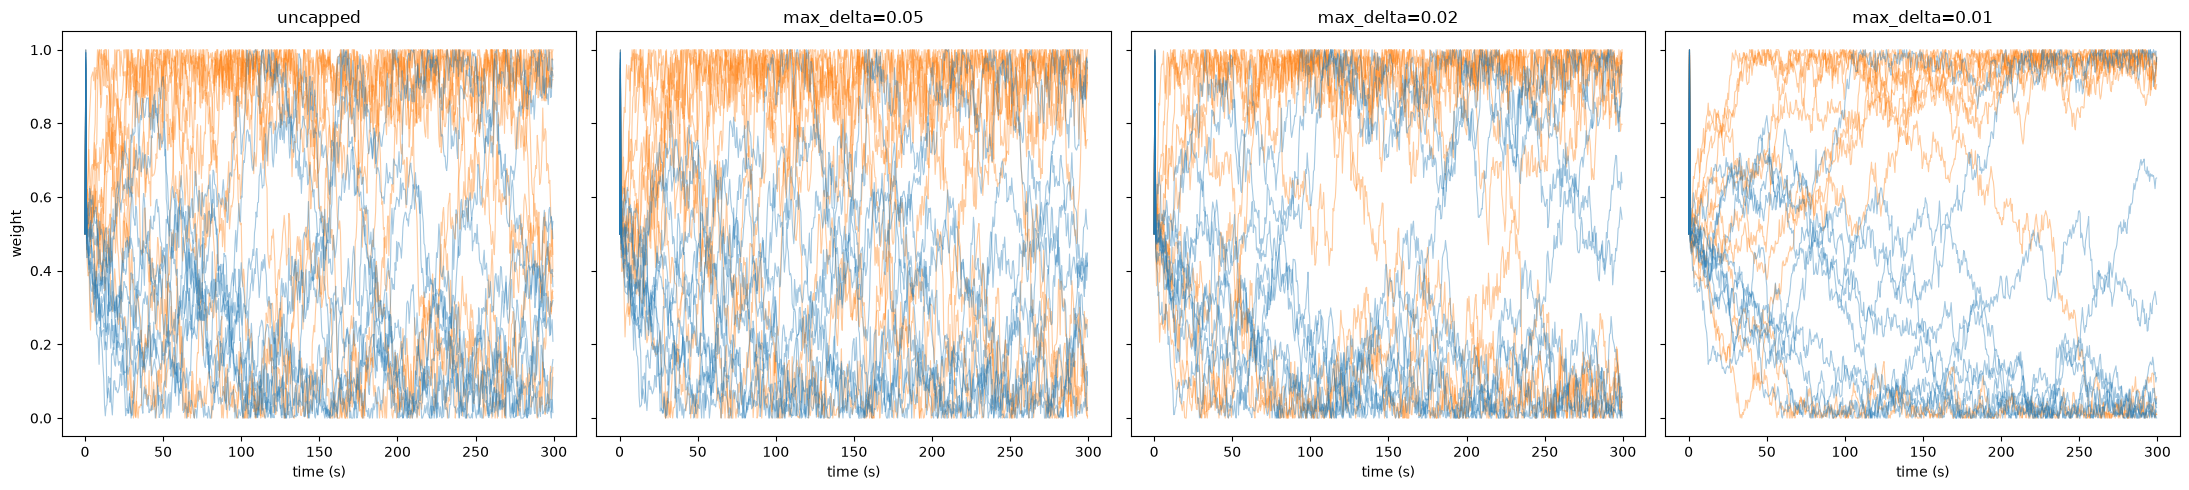

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
labels = [None, 0.05, 0.02, 0.01]
for ax, max_delta in zip(axes, labels):
    res = cap_results[max_delta]
    trace = res['weight_trace']
    t_trace = res['trace_t']
    for i in range(10):
        ax.plot(t_trace, trace[i], color='tab:orange', alpha=0.4, linewidth=0.8)
    for i in range(10, 20):
        ax.plot(t_trace, trace[i], color='tab:blue', alpha=0.4, linewidth=0.8)
    title = "uncapped" if max_delta is None else f"max_delta={max_delta}"
    ax.set_title(title)
    ax.set_xlabel('time (s)')
axes[0].set_ylabel('weight')
plt.tight_layout()
plt.savefig('stdp_jump_cap_trajectories.png', dpi=100)
plt.show()

In [6]:
print(f"{'condition':>14} {'late corr_w std':>17} {'late uncorr_w std':>19} {'gap 40-60%':>12} {'gap 80-100%':>13}")
for max_delta in labels:
    res = cap_results[max_delta]
    trace = res['weight_trace']
    t_trace = res['trace_t']
    n = len(t_trace)
    late_slice = slice(int(n*0.8), n)
    mid_slice = slice(int(n*0.4), int(n*0.6))
    late_corr_std = trace[:10, late_slice].std()
    late_uncorr_std = trace[10:, late_slice].std()
    mid_gap = trace[:10, mid_slice].mean() - trace[10:, mid_slice].mean()
    late_gap = trace[:10, late_slice].mean() - trace[10:, late_slice].mean()
    label = "uncapped" if max_delta is None else f"max_delta={max_delta}"
    print(f"{label:>14} {late_corr_std:>17.3f} {late_uncorr_std:>19.3f} {mid_gap:>12.3f} {late_gap:>13.3f}")

     condition   late corr_w std   late uncorr_w std   gap 40-60%   gap 80-100%
      uncapped             0.333               0.318        0.262         0.284
max_delta=0.05             0.374               0.304        0.309         0.250
max_delta=0.02             0.418               0.362        0.271         0.169
max_delta=0.01             0.421               0.366        0.447         0.376


## Verdict: hypothesis REJECTED too -- second rejection in a row for this instability

**Per-event jump-size capping does not produce the stable-separation shape seen at
Apre=0.005.** uncapped, max_delta=0.05, and max_delta=0.02 all look essentially identical in
the trajectory plot -- chaotic, full-range fluctuation for both groups throughout the entire
300s. At the tightest tested cap (max_delta=0.01), the character of the trajectory changes,
but not in the direction the hypothesis predicted: individual synapses move more *slowly*
(smaller per-event steps, as expected), but they are still wandering across the *full*
`[0,1]` range over the 300s window -- a slower random walk, not a converged, settled state.
This is visually and qualitatively different from Apre=0.005's shape (correlated synapses
climb and hold near the ceiling, uncorrelated synapses settle into a lower band with slow but
directional drift, not an unbounded back-and-forth wander).

**The late-window variance numbers confirm this, and explain the earlier-looking "signal" in
the wrong direction:** late-window within-group std *increases* monotonically as the cap
tightens (uncapped 0.333 -> 0.05 0.374 -> 0.02 0.418 -> 0.01 0.421) -- the opposite of what
"capping fixes it" would predict. This isn't evidence of the cap making things worse; it's an
artifact of the process being slower at tight caps, so even after 300s it's covered less
ground toward whatever its (apparently nonexistent, in this regime) equilibrium would be --
consistent with "still a random walk, just a slower one," not "converging, just not there
yet."

**The endpoint diffs (uncapped=+0.182, 0.05=+0.184, 0.02=+0.186, 0.01=+0.381) would have been
misleading on their own again** -- the same trap flagged and confirmed twice already this
session. The 0.01 condition's larger endpoint diff isn't evidence of better convergence; it's
consistent with a slower random walk that simply hadn't wandered as far from its current
position by the time the 300s cutoff hit, the same "chance of where you happened to look"
issue as the previous round.

**This is now the second cleanly-rejected hypothesis in a row for the same instability**
(scaling-interval timing, then per-event jump-size), both isolated and tested independently
of Apre's raw magnitude. That pattern itself is informative: it suggests the instability may
not decompose cleanly into "how often is the sum corrected" or "how big is one event's jump"
at all -- it may simply be that Apre's overall magnitude acts like an effective temperature
parameter for this competitive, zero-sum (via synaptic scaling) stochastic system, and no
attempt to hold Apre's magnitude fixed while isolating one contributing factor at a time has
found the actual lever, because the lever might not be separable that way in this system.

**Not chasing this further within this round.** Both proposed mechanisms are now cleanly
ruled out. The natural next hypothesis -- does directly lowering Apre's raw magnitude (even
un-decomposed, accepting the smaller-jumps/slower-accumulation confound this round tried to
avoid) produce a smooth transition from chaotic to stable, i.e. is there a threshold Apre
below which this regime changes character -- is a real, testable next step, but a new one,
not something to test unilaterally here. Flagging for discussion rather than continuing to
generate and test hypotheses independently.